# RQ3 Assignment 4: Crash Severity Classification

Research Question 3:

**Can crash severity be anticipated using variables like time interval, location type, and the number of traffic units involved?**

classification methods used:

- Naive Bayes Classifier
- Decision Tree Classifier
- Random Forest Classifier

In [3]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from zipfile import ZipFile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## 1. Load Dataset

In [5]:
possible_csv_paths = [
    Path("data/nsw_crash_traffic_volume_analysis_ready.csv"),
    Path("traffic_enriched_dataset/nsw_crash_traffic_volume_analysis_ready.csv"),
    Path("nsw_crash_traffic_volume_analysis_ready.csv"),
    Path.home() / "Downloads" / "nsw_crash_traffic_volume_analysis_ready.csv",
    Path.home() / "Downloads" / "traffic_enriched_dataset" / "nsw_crash_traffic_volume_analysis_ready.csv",
]

possible_zip_paths = [
    Path("data/nsw_crash_traffic_volume_analysis_ready.csv.zip"),
    Path("data/nsw_crash_traffic_volume_analysis_ready.zip"),
    Path("nsw_crash_traffic_volume_analysis_ready.csv.zip"),
    Path("nsw_crash_traffic_volume_analysis_ready.zip"),
    Path.home() / "Downloads" / "nsw_crash_traffic_volume_analysis_ready.csv.zip",
    Path.home() / "Downloads" / "nsw_crash_traffic_volume_analysis_ready.zip",
]

data_source = None
for path in possible_csv_paths:
    if path.exists():
        data_source = path
        df = pd.read_csv(path, low_memory=False)
        break

if data_source is None:
    for path in possible_zip_paths:
        if path.exists():
            data_source = path
            with ZipFile(path) as zf:
                csv_names = [name for name in zf.namelist() if name.endswith(".csv")]
                if not csv_names:
                    raise FileNotFoundError("No CSV file found inside zip file.")
                with zf.open(csv_names[0]) as file:
                    df = pd.read_csv(file, low_memory=False)
            break

if data_source is None:
    raise FileNotFoundError("Could not find nsw_crash_traffic_volume_analysis_ready.csv or zipped version.")

print("Loaded:", data_source)
print("Shape:", df.shape)
df.head()

Loaded: traffic_enriched_dataset/nsw_crash_traffic_volume_analysis_ready.csv
Shape: (47092, 95)


,crash_row_id,Year of crash,Month of crash,Day of week of crash,Street of crash,Street type,Town,LGA,Latitude,Longitude,...,light_vehicles_all_days,light_vehicles_am_peak,light_vehicles_pm_peak,light_vehicles_weekdays,light_vehicles_weekends,unclassified_all_days,unclassified_am_peak,unclassified_pm_peak,unclassified_weekdays,unclassified_weekends
0,1,2020,January,Friday,PACIFIC,HWY,BOM BOM,Clarence Valley,-29.745446,152.993909,...,NaN,NaN,NaN,NaN,NaN,6278.0,1486.0,1303.0,6630.0,5603.0
1,3,2020,January,Sunday,MARSDEN,RD,EASTWOOD,Ryde,-33.796520,151.065251,...,NaN,NaN,NaN,NaN,NaN,11230.0,2832.0,3174.0,11560.0,10499.0
2,5,2020,January,Friday,BUCKETTS,WAY,TWELVE MILE CREEK,Port Stephens,-32.643762,151.868062,...,5696.0,1390.0,1740.0,5532.0,6210.0,NaN,NaN,NaN,NaN,NaN
3,6,2020,January,Tuesday,YAMBA,RD,MACLEAN,Clarence Valley,-29.441917,153.212872,...,8258.0,2244.0,2622.0,9004.0,6428.0,NaN,NaN,NaN,NaN,NaN
4,9,2020,January,Monday,KIDMAN,WAY,THARBOGANG,Griffith,-34.249547,145.980776,...,4704.0,1300.0,1526.0,5172.0,3266.0,NaN,NaN,NaN,NaN,NaN


In [6]:
df.info()
df[["Degree of crash", "Two-hour intervals", "Type of location", "No. of traffic units involved"]].head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47092 entries, 0 to 47091
Data columns (total 95 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   crash_row_id                         47092 non-null  int64  
 1   Year of crash                        47092 non-null  int64  
 2   Month of crash                       47092 non-null  object 
 3   Day of week of crash                 47092 non-null  object 
 4   Street of crash                      47092 non-null  object 
 5   Street type                          47092 non-null  object 
 6   Town                                 47092 non-null  object 
 7   LGA                                  47092 non-null  object 
 8   Latitude                             47092 non-null  float64
 9   Longitude                            47092 non-null  float64
 10  Degree of crash                      47092 non-null  object 
 11  No. of traffic units involve

,Degree of crash,Two-hour intervals,Type of location,No. of traffic units involved
0,Fatal,22:00 - Midnight,T-junction,2
1,Fatal,22:00 - Midnight,X-intersection,2
2,Fatal,12:00 - 13:59,2-way undivided,1
3,Fatal,02:00 - 03:59,2-way undivided,1
4,Fatal,20:00 - 21:59,2-way undivided,2


## 2. Create RQ3 Classification Target

RQ3 is about crash severity. The raw severity field is `Degree of crash`, which includes:

- Fatal
- Injury
- Non-casualty (towaway)

Fatal crashes are rare, so we will create a binary severity target:

- `1 = casualty crash`, where the crash was Fatal or Injury
- `0 = non-casualty crash`, where the crash was Non-casualty (towaway)

This is still a crash-severity classification task, but it avoids the modelling problem caused by the very small fatal class.

In [8]:
df["Degree of crash"] = df["Degree of crash"].astype(str).str.strip()

df["casualty_crash"] = df["Degree of crash"].isin(["Fatal", "Injury"]).astype(int)

target_counts = df["casualty_crash"].value_counts().sort_index()
target_rates = df["casualty_crash"].value_counts(normalize=True).sort_index()
target_summary = pd.DataFrame({"count": target_counts, "rate": target_rates})
target_summary.index = ["Non-casualty crash", "Casualty crash"]
target_summary

,count,rate
Non-casualty crash,15118,0.321031
Casualty crash,31974,0.678969


In [9]:
degree_summary = df["Degree of crash"].value_counts().rename_axis("degree_of_crash").reset_index(name="count")
degree_summary["rate"] = degree_summary["count"] / len(df)
degree_summary

,degree_of_crash,count,rate
0,Injury,31454,0.667927
1,Non-casualty (towaway),15118,0.321031
2,Fatal,520,0.011042


## 3. Feature Engineering

These engineered features are created from suitable crash variables:

- `is_peak_time`: crash occurred during morning or afternoon peak periods
- `is_late_night`: crash occurred late at night or early morning
- `is_intersection`: crash occurred at T-junction, X-intersection, or roundabout
- `is_high_speed`: speed limit is 80 km/h or above
- `traffic_units_group`: grouped number of traffic units involved
- `log_all_vehicles_all_days`: log-transformed traffic volume
- `heavy_vehicle_share_available`: whether heavy vehicle share was available

In [11]:
def is_peak_interval(value):
    text = str(value)
    return int(any(interval in text for interval in ["06:00 - 07:59", "08:00 - 09:59", "16:00 - 17:59", "18:00 - 19:59"]))


def is_late_night_interval(value):
    text = str(value)
    return int(any(interval in text for interval in ["22:00 - Midnight", "00:00 - 01:59", "02:00 - 03:59", "04:00 - 05:59"]))


df["Speed_limit_num"] = pd.to_numeric(df["Speed_limit_num"], errors="coerce")
df["No. of traffic units involved"] = pd.to_numeric(df["No. of traffic units involved"], errors="coerce")
df["all_vehicles_all_days"] = pd.to_numeric(df["all_vehicles_all_days"], errors="coerce")
df["heavy_vehicle_share_all_days"] = pd.to_numeric(df["heavy_vehicle_share_all_days"], errors="coerce")

df["is_peak_time"] = df["Two-hour intervals"].apply(is_peak_interval)
df["is_late_night"] = df["Two-hour intervals"].apply(is_late_night_interval)
df["is_intersection"] = df["Type of location"].astype(str).isin(["T-junction", "X-intersection", "Roundabout"]).astype(int)
df["is_high_speed"] = (df["Speed_limit_num"] >= 80).astype(int)
df["log_all_vehicles_all_days"] = np.log1p(df["all_vehicles_all_days"])
df["heavy_vehicle_share_available"] = df["heavy_vehicle_share_all_days"].notna().astype(int)

df["traffic_units_group"] = pd.cut(
    df["No. of traffic units involved"],
    bins=[0, 1, 2, 3, np.inf],
    labels=["1 unit", "2 units", "3 units", "4+ units"],
)

df[[
    "Two-hour intervals",
    "Type of location",
    "No. of traffic units involved",
    "traffic_units_group",
    "is_peak_time",
    "is_late_night",
    "is_intersection",
    "is_high_speed",
    "log_all_vehicles_all_days",
]].head()

,Two-hour intervals,Type of location,No. of traffic units involved,traffic_units_group,is_peak_time,is_late_night,is_intersection,is_high_speed,log_all_vehicles_all_days
0,22:00 - Midnight,T-junction,2,2 units,0,1,1,1,8.744966
1,22:00 - Midnight,X-intersection,2,2 units,0,1,1,0,9.326433
2,12:00 - 13:59,2-way undivided,1,1 unit,0,0,0,1,8.743691
3,02:00 - 03:59,2-way undivided,1,1 unit,0,1,0,1,9.074406
4,20:00 - 21:59,2-way undivided,2,2 units,0,0,0,1,8.574896


## 4. Exploratory Data Analysis

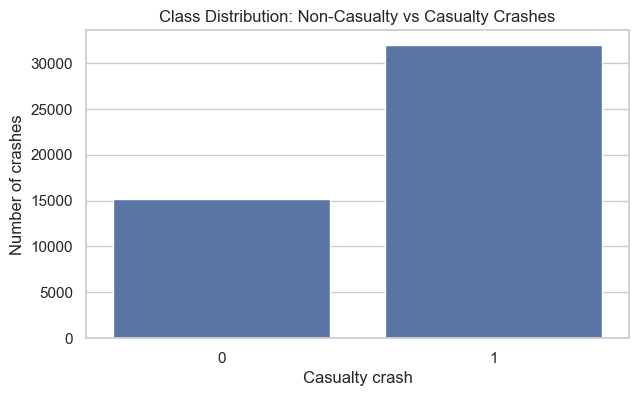

In [13]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="casualty_crash")
plt.title("Class Distribution: Non-Casualty vs Casualty Crashes")
plt.xlabel("Casualty crash")
plt.ylabel("Number of crashes")
plt.show()

,Type of location,count,casualty_rate
0,2-way undivided,12712,0.648128
1,T-junction,12487,0.705534
2,X-intersection,8571,0.709835
3,Divided road,8052,0.661451
4,Roundabout,2542,0.677026
5,Dual freeway,1870,0.636364
6,Other,328,0.698171
7,1-way street,274,0.718978
8,L-junction,90,0.588889
9,Single limited access,58,0.810345


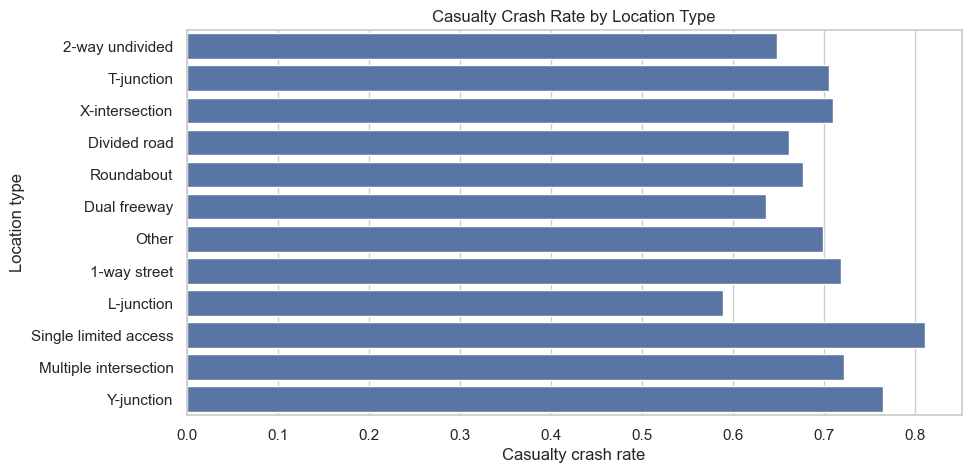

In [15]:
location_summary = (
    df.groupby("Type of location")["casualty_crash"]
    .agg(count="count", casualty_rate="mean")
    .sort_values("count", ascending=False)
    .reset_index()
)

display(location_summary.head(12))

plt.figure(figsize=(10, 5))
sns.barplot(data=location_summary.head(12), x="casualty_rate", y="Type of location")
plt.title("Casualty Crash Rate by Location Type")
plt.xlabel("Casualty crash rate")
plt.ylabel("Location type")
plt.show()

,Two-hour intervals,count,casualty_rate
0,00:01 - 01:59,1380,0.543478
1,02:00 - 03:59,1051,0.503330
2,04:00 - 05:59,1516,0.609499
3,06:00 - 07:59,3803,0.687089
4,08:00 - 09:59,4988,0.708300
5,10:00 - 11:59,4998,0.699480
6,12:00 - 13:59,5439,0.720169
7,14:00 - 15:59,6567,0.705954
8,16:00 - 17:59,7103,0.697170
9,18:00 - 19:59,4663,0.674887


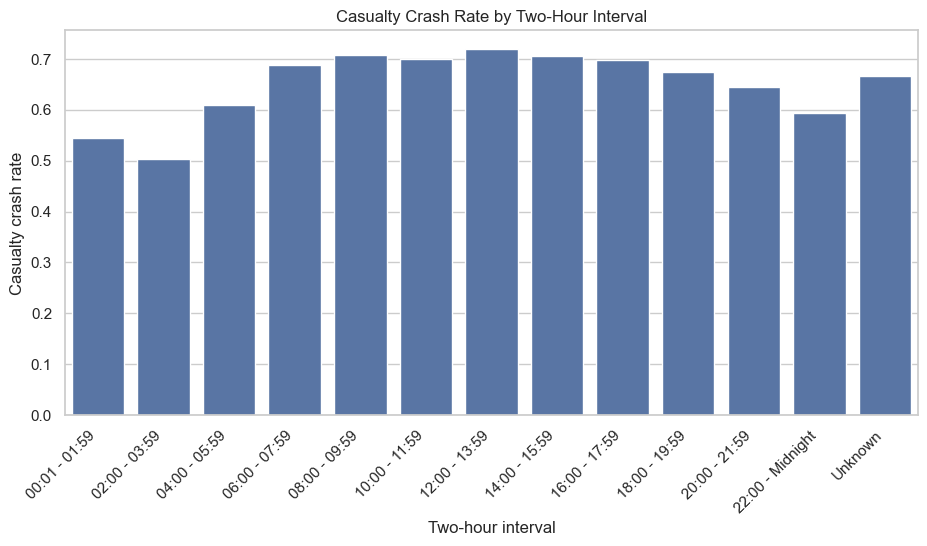

In [16]:
time_summary = (
    df.groupby("Two-hour intervals")["casualty_crash"]
    .agg(count="count", casualty_rate="mean")
    .reset_index()
)

display(time_summary)

plt.figure(figsize=(11, 5))
sns.barplot(data=time_summary, x="Two-hour intervals", y="casualty_rate")
plt.title("Casualty Crash Rate by Two-Hour Interval")
plt.xlabel("Two-hour interval")
plt.ylabel("Casualty crash rate")
plt.xticks(rotation=45, ha="right")
plt.show()

,traffic_units_group,count,casualty_rate
0,1 unit,9542,0.615280
1,2 units,31165,0.700947
2,3 units,4935,0.666059
3,4+ units,1450,0.669655


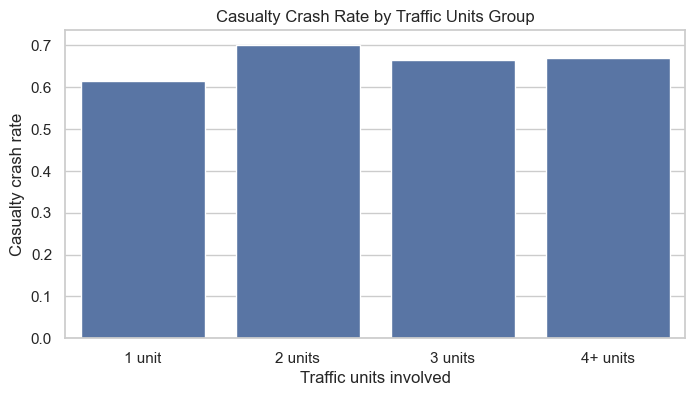

In [17]:
units_summary = (
    df.groupby("traffic_units_group", observed=True)["casualty_crash"]
    .agg(count="count", casualty_rate="mean")
    .reset_index()
)

display(units_summary)

plt.figure(figsize=(8, 4))
sns.barplot(data=units_summary, x="traffic_units_group", y="casualty_rate")
plt.title("Casualty Crash Rate by Traffic Units Group")
plt.xlabel("Traffic units involved")
plt.ylabel("Casualty crash rate")
plt.show()

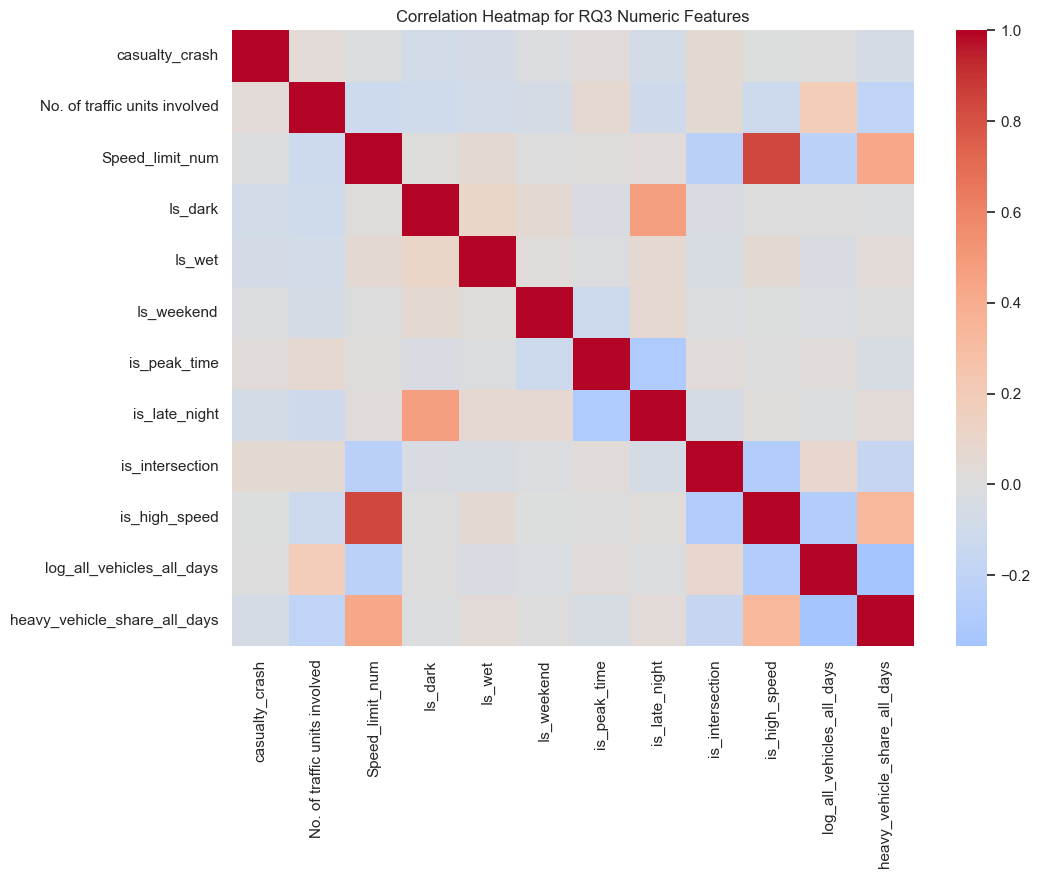

In [18]:
numeric_for_corr = [
    "casualty_crash",
    "No. of traffic units involved",
    "Speed_limit_num",
    "Is_dark",
    "Is_wet",
    "Is_weekend",
    "is_peak_time",
    "is_late_night",
    "is_intersection",
    "is_high_speed",
    "log_all_vehicles_all_days",
    "heavy_vehicle_share_all_days",
]
numeric_for_corr = [c for c in numeric_for_corr if c in df.columns]
corr_df = df[numeric_for_corr].apply(pd.to_numeric, errors="coerce")

plt.figure(figsize=(11, 8))
sns.heatmap(corr_df.corr(), cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap for RQ3 Numeric Features")
plt.show()

## 5. Define Model Features

The core RQ3 variables are time interval, location type, and number of traffic units involved. Additional crash and enrichment variables are included to improve classification.

In [25]:
numeric_features = [
    "No. of traffic units involved",
    "Speed_limit_num",
    "Is_dark",
    "Is_wet",
    "Is_weekend",
    "Month_num",
    "Day_num",
    "is_peak_time",
    "is_late_night",
    "is_intersection",
    "is_high_speed",
    "log_all_vehicles_all_days",
    "heavy_vehicle_share_all_days",
    "heavy_vehicle_share_available",
]

categorical_features = [
    "Two-hour intervals",
    "Type of location",
    "traffic_units_group",
    "Urbanisation",
    "Road surface",
    "Weather",
    "Natural lighting",
    "matched_station_road_classification",
    "matched_station_road_hierarchy",
    "matched_station_lane_count",
]

numeric_features = [c for c in numeric_features if c in df.columns]
categorical_features = [c for c in categorical_features if c in df.columns]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['No. of traffic units involved', 'Speed_limit_num', 'Is_dark', 'Is_wet', 'Is_weekend', 'Month_num', 'Day_num', 'is_peak_time', 'is_late_night', 'is_intersection', 'is_high_speed', 'log_all_vehicles_all_days', 'heavy_vehicle_share_all_days', 'heavy_vehicle_share_available']
Categorical features: ['Two-hour intervals', 'Type of location', 'traffic_units_group', 'Urbanisation', 'Road surface', 'Weather', 'Natural lighting', 'matched_station_road_classification', 'matched_station_road_hierarchy', 'matched_station_lane_count']


## 6. Train/Test Split

In [31]:
target = "casualty_crash"
features = numeric_features + categorical_features

model_df = df[features + [target]].dropna(subset=[target]).copy()
X = model_df[features]
y = model_df[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE,
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train target rate:", y_train.mean())
print("Test target rate:", y_test.mean())

Train shape: (32964, 24)
Test shape: (14128, 24)
Train target rate: 0.6789831331149132
Test target rate: 0.6789354473386183


## 7. Preprocessing Pipeline

In [36]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

## 8. Build Models 



In [67]:
# Naive Bayes needs dense input, so it uses a separate preprocessing pipeline.
nb_numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

nb_categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

nb_preprocessor = ColumnTransformer(
    transformers=[
        ("num", nb_numeric_transformer, numeric_features),
        ("cat", nb_categorical_transformer, categorical_features),
    ]
)

naive_bayes = Pipeline(
    steps=[
        ("preprocess", nb_preprocessor),
        ("model", GaussianNB()),
    ]
)

decision_tree = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", DecisionTreeClassifier(
            max_depth=8,
            min_samples_leaf=100,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )),
    ]
)

random_forest = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            max_depth=12,
            min_samples_leaf=50,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ]
)

naive_bayes.fit(X_train, y_train)
decision_tree.fit(X_train, y_train)
random_forest.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['No. of traffic units '
                                                   'involved',
                                                   'Speed_limit_num', 'Is_dark',
                                                   'Is_wet', 'Is_weekend',
                                                   'Month_num', 'Day_num',
                                                   'is_peak_time',
                                                   'is_late_night',
                                                   'is_intersection',
                                                   'is_high_speed',
                                                   'log_all_vehicles_all_...
                                                  ['Two-hour intervals',
                                                   'Type of location',
                                                   'traffic_units_group',
                                                   'Urbanisation',
                                                   'Road surface', 'Weather',
                                                   'Natural lighting',
                                                   'matched_station_road_classification',
                                                   'matched_station_road_hierarchy',
                                                   'matched_station_lane_count'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=12,
                                        min_samples_leaf=50, n_estimators=200,
                                        n_jobs=-1, random_state=42))])

## 9. Evaluation Helper

In [41]:
def evaluate_model(name, model, X_test_data, y_test_data):
    y_pred = model.predict(X_test_data)
    y_score = model.predict_proba(X_test_data)[:, 1]

    result = {
        "model": name,
        "accuracy": accuracy_score(y_test_data, y_pred),
        "precision": precision_score(y_test_data, y_pred, zero_division=0),
        "recall": recall_score(y_test_data, y_pred, zero_division=0),
        "f1": f1_score(y_test_data, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test_data, y_score),
    }

    print("\n", name)
    print(classification_report(y_test_data, y_pred, zero_division=0))

    ConfusionMatrixDisplay.from_predictions(y_test_data, y_pred)
    plt.title(f"Confusion Matrix: {name}")
    plt.show()

    RocCurveDisplay.from_predictions(y_test_data, y_score)
    plt.title(f"ROC Curve: {name}")
    plt.show()

    return result

## 10. Test Set Evaluation


 Naive Bayes
              precision    recall  f1-score   support

           0       0.42      0.19      0.26      4536
           1       0.70      0.88      0.78      9592

    accuracy                           0.66     14128
   macro avg       0.56      0.53      0.52     14128
weighted avg       0.61      0.66      0.61     14128



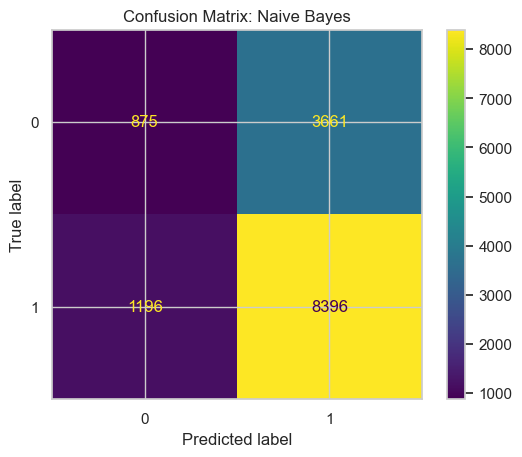

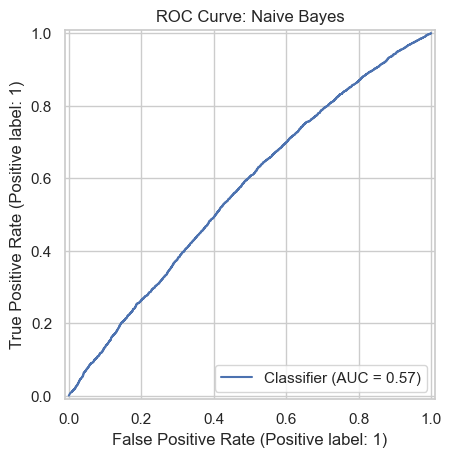


 Decision Tree
              precision    recall  f1-score   support

           0       0.38      0.51      0.44      4536
           1       0.73      0.61      0.66      9592

    accuracy                           0.58     14128
   macro avg       0.55      0.56      0.55     14128
weighted avg       0.62      0.58      0.59     14128



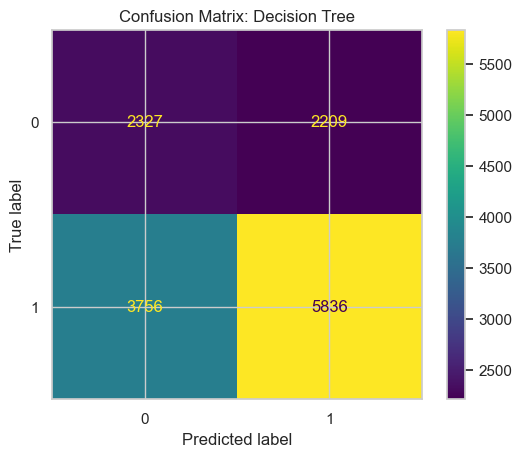

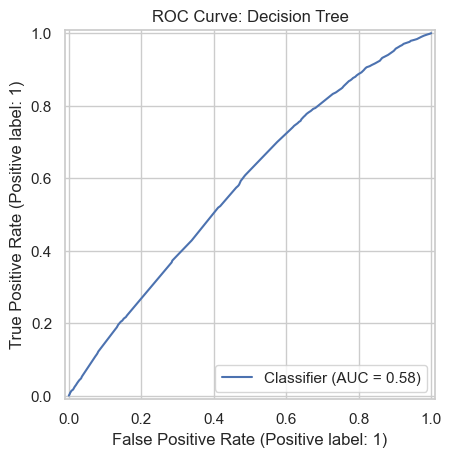


 Random Forest
              precision    recall  f1-score   support

           0       0.40      0.45      0.42      4536
           1       0.72      0.68      0.70      9592

    accuracy                           0.60     14128
   macro avg       0.56      0.56      0.56     14128
weighted avg       0.62      0.60      0.61     14128



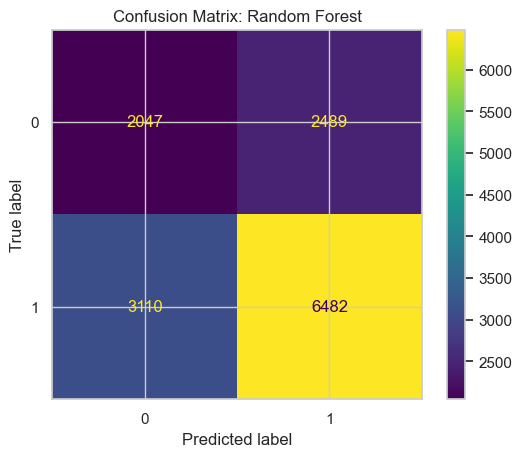

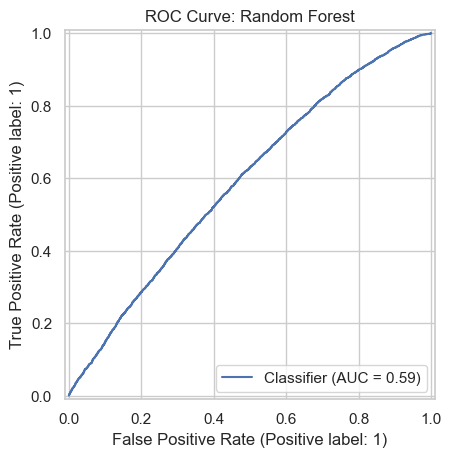

,model,accuracy,precision,recall,f1,roc_auc
0,Naive Bayes,0.656215,0.696359,0.875313,0.775648,0.567885
2,Random Forest,0.603695,0.722550,0.675771,0.698378,0.590730
1,Decision Tree,0.577789,0.725420,0.608424,0.661791,0.580587


In [43]:
test_results = []
test_results.append(evaluate_model("Naive Bayes", naive_bayes, X_test, y_test))
test_results.append(evaluate_model("Decision Tree", decision_tree, X_test, y_test))
test_results.append(evaluate_model("Random Forest", random_forest, X_test, y_test))

test_results_df = pd.DataFrame(test_results).sort_values("f1", ascending=False)
test_results_df

## 11. Cross-Validation

In [45]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

cv_models = {
    "Naive Bayes": naive_bayes,
    "Decision Tree": decision_tree,
    "Random Forest": random_forest,
}

cv_rows = []
for name, model in cv_models.items():
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    row = {"model": name}
    for metric in scoring:
        row[f"{metric}_mean"] = scores[f"test_{metric}"].mean()
        row[f"{metric}_std"] = scores[f"test_{metric}"].std()
    cv_rows.append(row)

cv_results_df = pd.DataFrame(cv_rows).sort_values("f1_mean", ascending=False)
cv_results_df

,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
0,Naive Bayes,0.653105,0.012935,0.700563,0.003423,0.854602,0.040155,0.769458,0.015013,0.574097,0.005327
2,Random Forest,0.610804,0.004482,0.725296,0.003639,0.686995,0.005831,0.705613,0.003853,0.595105,0.005445
1,Decision Tree,0.606748,0.019173,0.717223,0.003621,0.695159,0.050981,0.704921,0.026707,0.578500,0.005762


## 12. Hyperparameter Tuning

The Random Forest is tuned using grid search with five-fold cross-validation.

Best parameters: {'model__max_depth': 12, 'model__min_samples_leaf': 25, 'model__n_estimators': 150}
Best CV F1: 0.7090681187055073

 Tuned Random Forest
              precision    recall  f1-score   support

           0       0.41      0.43      0.42      4536
           1       0.72      0.70      0.71      9592

    accuracy                           0.61     14128
   macro avg       0.56      0.57      0.57     14128
weighted avg       0.62      0.61      0.62     14128



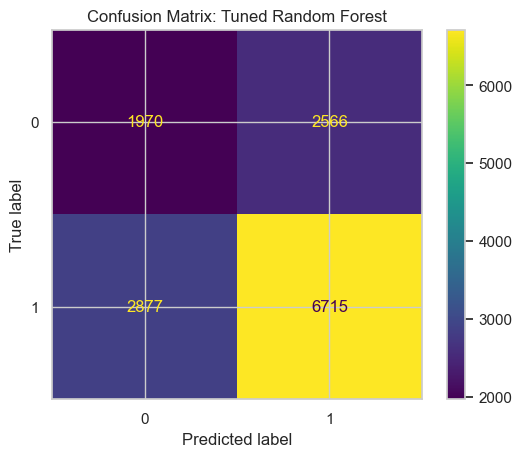

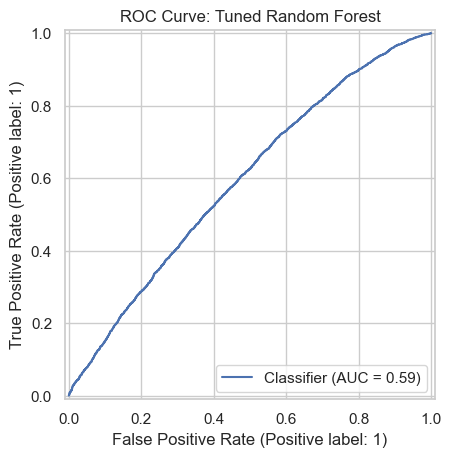

{'model': 'Tuned Random Forest',
 'accuracy': 0.6147366930917327,
 'precision': 0.723521172287469,
 'recall': 0.7000625521267723,
 'f1': 0.7115985799819848,
 'roc_auc': 0.5931562765230578}

In [49]:
rf_param_grid = {
    "model__n_estimators": [150, 250],
    "model__max_depth": [8, 12, None],
    "model__min_samples_leaf": [25, 50, 100],
}

rf_grid = GridSearchCV(
    estimator=random_forest,
    param_grid=rf_param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
)

rf_grid.fit(X_train, y_train)

print("Best parameters:", rf_grid.best_params_)
print("Best CV F1:", rf_grid.best_score_)

tuned_rf_result = evaluate_model("Tuned Random Forest", rf_grid.best_estimator_, X_test, y_test)
tuned_rf_result

## 13. Final Model Comparison

In [51]:
final_results_df = pd.DataFrame(test_results + [tuned_rf_result]).sort_values("f1", ascending=False)
final_results_df

,model,accuracy,precision,recall,f1,roc_auc
0,Naive Bayes,0.656215,0.696359,0.875313,0.775648,0.567885
3,Tuned Random Forest,0.614737,0.723521,0.700063,0.711599,0.593156
2,Random Forest,0.603695,0.722550,0.675771,0.698378,0.590730
1,Decision Tree,0.577789,0.725420,0.608424,0.661791,0.580587


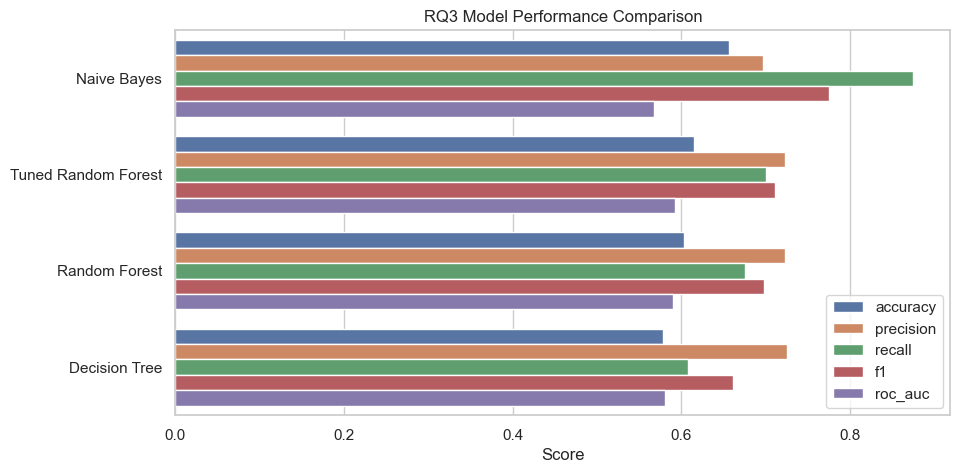

In [53]:
plot_df = final_results_df.melt(
    id_vars="model",
    value_vars=["accuracy", "precision", "recall", "f1", "roc_auc"],
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, x="score", y="model", hue="metric")
plt.title("RQ3 Model Performance Comparison")
plt.xlabel("Score")
plt.ylabel("")
plt.legend(loc="lower right")
plt.show()

## 14. Feature Importance

,feature,importance
11,num__log_all_vehicles_all_days,0.105599
1,num__Speed_limit_num,0.073525
5,num__Month_num,0.057698
6,num__Day_num,0.043345
57,cat__Natural lighting_Darkness,0.040842
59,cat__Natural lighting_Daylight,0.038961
0,num__No. of traffic units involved,0.038528
12,num__heavy_vehicle_share_all_days,0.037254
2,num__Is_dark,0.033670
51,cat__Weather_Fine,0.033611


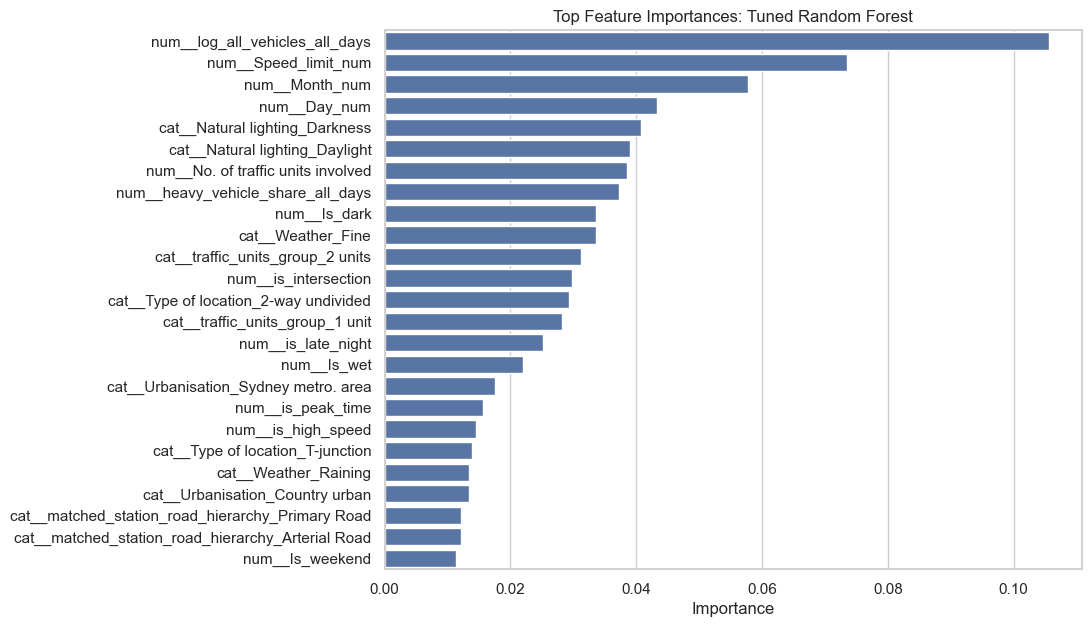

In [55]:
best_model = rf_grid.best_estimator_
preprocessor = best_model.named_steps["preprocess"]
rf_model = best_model.named_steps["model"]

feature_names = preprocessor.get_feature_names_out()
feature_importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": rf_model.feature_importances_})
    .sort_values("importance", ascending=False)
    .head(25)
)

display(feature_importance_df)

plt.figure(figsize=(9, 7))
sns.barplot(data=feature_importance_df, x="importance", y="feature")
plt.title("Top Feature Importances: Tuned Random Forest")
plt.xlabel("Importance")
plt.ylabel("")
plt.show()

## 15. Export Results

In [57]:
OUTPUT_DIR = Path.home() / "Downloads" / "rq3_model_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

target_summary.to_csv(OUTPUT_DIR / "rq3_target_distribution.csv")
degree_summary.to_csv(OUTPUT_DIR / "rq3_degree_of_crash_distribution.csv", index=False)
location_summary.to_csv(OUTPUT_DIR / "rq3_location_type_summary.csv", index=False)
time_summary.to_csv(OUTPUT_DIR / "rq3_time_interval_summary.csv", index=False)
units_summary.to_csv(OUTPUT_DIR / "rq3_traffic_units_summary.csv", index=False)
test_results_df.to_csv(OUTPUT_DIR / "rq3_model_test_results.csv", index=False)
cv_results_df.to_csv(OUTPUT_DIR / "rq3_cross_validation_results.csv", index=False)
final_results_df.to_csv(OUTPUT_DIR / "rq3_final_model_results.csv", index=False)
feature_importance_df.to_csv(OUTPUT_DIR / "rq3_feature_importance.csv", index=False)

print("Saved outputs to:", OUTPUT_DIR.resolve())

Saved outputs to: /Users/alanjoshi/Downloads/rq3_model_outputs
